<a href="https://colab.research.google.com/github/JungYeoni/study_torch/blob/main/ML/Linear%20Regression/%EB%AF%B8%EB%8B%88_%EB%B0%B0%EC%B9%98%EC%99%80_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%A1%9C%EB%8D%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 미니 배치와 데이터 로더(Mini Batch and DataLoader)

학습 자료
> https://wikidocs.net/55580

미니 배치 (mini batch): 전체 데이터를 더 작은 단위로 나누어서 학습하는 개념

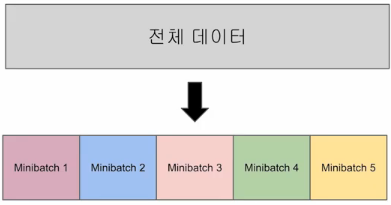

미니 배치 학습을 하게되면 미니 배치만큼 가져가서  미니 배치에 대한 비용을 계산하고, 경사하강법을 수행함

배치 크기 (batch size): 미니 배치의 크기
- 미니 배치의 개수는 미니 배치의 크기를 몇으로 하느냐에 따라서 달라짐.
- 배치 크기는 보통 2의 제곱수를 사용함 (CPU, GPU 메모리가 2의 배수이기 때문에, 데이터의 송수신 효율을 높일 수 있음)

배치 경사 하강법: 전체 데이터에서 대해서 한 번에 경사하강법을 수행하는 방법
- 가중치 값이 최적값에 수렴하는 과정이 안정적이지만 계산량이 많음.

미니 배치 경사 하강법: 미니 배치 단위로 경사하강법을 수행하는 방법   
- 전체 데이터의 일부만을보고 수행 -> 최적값으로 수렴하는 과정에서 헤맬 수 있으나 훈련 속도가 빠름

이터레이션: 파라미터 업데이트 횟수



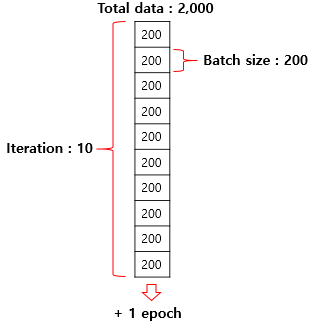

## 데이터 로드하기

- 기본적인 사용 방법은 Dataset 을 정의하고, 이를 DataLoader에 전달한다

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset # 텐서 데이터셋
from torch.utils.data import DataLoader # 데이터로더

In [12]:
torch.manual_seed(1)

In [13]:
# 데이터 정의
x_train  =  torch.FloatTensor([[73,  80,  75],
                               [93,  88,  93],
                               [89,  91,  90],
                               [96,  98,  100],
                               [73,  66,  70]])
y_train  =  torch.FloatTensor([[152],  [185],  [180],  [196],  [142]])

In [14]:
# 이를 TensorDataset 의 입력으로 사용하고 dataset으로 저장
dataset = TensorDataset(x_train, y_train)

- 데이터로더는 기본적으로 2개의 인자를 입력받음
--> 데이터셋, 미니 배치 크기
- 추가적으로 `shuffle` 인자는 에포크마다 데이터셋을 섞어서 데이터가 학습되는 순서를 바꿈
--> 모델이 데이터셋 순서에 익숙해지는 것을 방지

In [15]:
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [16]:
# 모델과 옵티마이저 설계
model = nn.Linear(3, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5)

In [17]:
# 훈련 진행
nb_epochs = 20

for epoch in range(nb_epochs + 1):
  for batch_idx, samples in enumerate(dataloader):
    print('batch_idx = ', batch_idx)
    print('samples = ', samples)
    x_train, y_train = samples

    prediction = model(x_train)

    cost = F.mse_loss(prediction, y_train)

    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    print('Epoch {:4d}/{} Batch: {}/{} Cost:  {:.6f}'.format(
        epoch, nb_epochs, batch_idx + 1, len(dataloader), cost.item()
    ))
    print('----------------------------------------------------------')

batch_idx =  0
samples =  [tensor([[73., 66., 70.],
        [73., 80., 75.]]), tensor([[142.],
        [152.]])]
Epoch    0/20 Batch: 1/3 Cost:  23071.781250
----------------------------------------------------------
batch_idx =  1
samples =  [tensor([[ 89.,  91.,  90.],
        [ 96.,  98., 100.]]), tensor([[180.],
        [196.]])]
Epoch    0/20 Batch: 2/3 Cost:  17581.359375
----------------------------------------------------------
batch_idx =  2
samples =  [tensor([[93., 88., 93.]]), tensor([[185.]])]
Epoch    0/20 Batch: 3/3 Cost:  3703.553467
----------------------------------------------------------
batch_idx =  0
samples =  [tensor([[ 73.,  80.,  75.],
        [ 96.,  98., 100.]]), tensor([[152.],
        [196.]])]
Epoch    1/20 Batch: 1/3 Cost:  857.131836
----------------------------------------------------------
batch_idx =  1
samples =  [tensor([[89., 91., 90.],
        [73., 66., 70.]]), tensor([[180.],
        [142.]])]
Epoch    1/20 Batch: 2/3 Cost:  194.912628
--------

In [18]:
# 임의의 입력으로 예측하기
new_var = torch.FloatTensor([[73, 80, 75]])
pred_y = model(new_var)
print("훈련 후 입력이 73, 80, 75일 때의 예측값 :", pred_y)

훈련 후 입력이 73, 80, 75일 때의 예측값 : tensor([[151.0829]], grad_fn=<AddmmBackward0>)


## 커스텀 데이터셋(Custom Dataset)

`torch.utils.data.Dataset`을 상속받아 직접 커스텀 데이터셋을 만드는 경
- `torch.utils.data.Dataset`: 파이토치에서 데이터셋을 제공하는 추상 클래스

```python
# 커스텀 데이터셋을 만들 때의 기본적인 뼈대
class CustomDataset(torch.utils.data.Dataset):
  def __init__(self):
    데이터셋의 전처리를 해주는 부분

  def __len__(self):
    데이터셋의 길이, 즉 총 샘플 수를 적어주는 부분

  def __getitem__(self, idx):
    데이터셋에서 특정 1개의 샘플을 가져오는 함수
```

## 커스텀 데이터셋(Custom Dataset)으로 선형 회귀 구현하기

In [19]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [20]:
# Dataset 상속
class CustomDataset(Dataset):
  def __init__(self):
    self.x_data = [[73, 80, 75],
                    [93, 88, 93],
                    [89, 91, 90],
                    [96, 98, 100],
                    [73, 66, 70]]
    self.y_data = [[152], [185], [180], [196], [142]]

  # 총 데이터의 개수를 리턴
  def __len__(self):
    return len(self.x_data)

  # 인덱스를 입력받아 그에 맵핑되는 입출력 데이터를 토치의 Tensor 형태로 리턴
  def __getitem__(self, idx):
    x = torch.FloatTensor(self.x_data[idx])
    y = torch.FloatTensor(self.y_data[idx])

    return x, y

- PyTorch 의 Dataset 클래스를 상속받아 사용자 정의 데이터셋 클래스를 만드는 방법을 보여줌
- 클래스가 초기화될 때 두 데이터를 내부 변수로 저장함.

In [21]:
dataset = CustomDataset()
dataloader= DataLoader(dataset, batch_size=2, shuffle=True)

In [22]:
model = torch.nn.Linear(3, 1) # 회귀 모델 정의
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5)

In [23]:
# 훈련 진행
nb_epochs = 20

for epoch in range(nb_epochs + 1):
  for batch_idx, samples in enumerate(dataloader):
    print('batch_idx = ', batch_idx)
    print('samples = ', samples)
    x_train, y_train = samples

    prediction = model(x_train)

    cost = F.mse_loss(prediction, y_train)

    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    print('Epoch {:4d}/{} Batch: {}/{} Cost:  {:.6f}'.format(
        epoch, nb_epochs, batch_idx + 1, len(dataloader), cost.item()
    ))
    print('----------------------------------------------------------')

batch_idx =  0
samples =  [tensor([[93., 88., 93.],
        [73., 66., 70.]]), tensor([[185.],
        [142.]])]
Epoch    0/20 Batch: 1/3 Cost:  17413.818359
----------------------------------------------------------
batch_idx =  1
samples =  [tensor([[ 89.,  91.,  90.],
        [ 96.,  98., 100.]]), tensor([[180.],
        [196.]])]
Epoch    0/20 Batch: 2/3 Cost:  7685.123535
----------------------------------------------------------
batch_idx =  2
samples =  [tensor([[73., 80., 75.]]), tensor([[152.]])]
Epoch    0/20 Batch: 3/3 Cost:  1045.926636
----------------------------------------------------------
batch_idx =  0
samples =  [tensor([[ 89.,  91.,  90.],
        [ 96.,  98., 100.]]), tensor([[180.],
        [196.]])]
Epoch    1/20 Batch: 1/3 Cost:  740.764893
----------------------------------------------------------
batch_idx =  1
samples =  [tensor([[93., 88., 93.],
        [73., 80., 75.]]), tensor([[185.],
        [152.]])]
Epoch    1/20 Batch: 2/3 Cost:  173.894516
---------

In [24]:
# 임의의 입력으로 예측하기
new_var = torch.FloatTensor([[73, 80, 75]])
pred_y = model(new_var)
print("훈련 후 입력이 73, 80, 75일 때의 예측값 :", pred_y)

훈련 후 입력이 73, 80, 75일 때의 예측값 : tensor([[153.5690]], grad_fn=<AddmmBackward0>)
